In [1]:
from kafka import KafkaConsumer
import json
import matplotlib.pyplot as plt
import time

### Ejercicio 2

#### Ejercicio 2.2

In [2]:
# Initialize data storage for plotting
timestamps = []
water_temperatures = []
ph_levels = []
turbidities = []
dissolved_oxygen_levels = []

In [ ]:
# Kafka configuration
def initialize_consumer():
    kafka_topic = "water_quality"
    kafka_bootstrap_servers = ["localhost:9092"]

    # Create Kafka consumer
    consumer = KafkaConsumer(
        kafka_topic,
        bootstrap_servers=kafka_bootstrap_servers,
        value_deserializer=lambda m: json.loads(m.decode('utf-8')),
        auto_offset_reset='latest',
        enable_auto_commit=True
    )
    return consumer

In [3]:
# Receive all published messages and update plot
def update_plot(consumer):
    try:
        for message in consumer:
            # Parse the message
            sensor_data = message.value
            print(f"Received: {sensor_data}")

            # Update data storage
            timestamps.append(sensor_data['timestamp'])
            water_temperatures.append(sensor_data['water_temperature'])
            ph_levels.append(sensor_data['ph_level'])
            turbidities.append(sensor_data['turbidity'])
            dissolved_oxygen_levels.append(sensor_data['dissolved_oxygen'])

            # Keep only the last 100 entries for plotting
            if len(timestamps) > 100:
                timestamps.pop(0)
                water_temperatures.pop(0)
                ph_levels.pop(0)
                turbidities.pop(0)
                dissolved_oxygen_levels.pop(0)

            # Clear the current axes and redraw the plots
            plt.figure(figsize=(10, 8))

            plt.subplot(2, 2, 1)
            plt.plot(timestamps, water_temperatures, label="Water Temperature", color="blue")
            plt.title("Water Temperature")
            plt.ylabel("°C")

            plt.subplot(2, 2, 2)
            plt.plot(timestamps, ph_levels, label="pH Level", color="green")
            plt.title("pH Level")
            plt.ylabel("pH")

            plt.subplot(2, 2, 3)
            plt.plot(timestamps, turbidities, label="Turbidity", color="orange")
            plt.title("Turbidity")
            plt.ylabel("NTU")

            plt.subplot(2, 2, 4)
            plt.plot(timestamps, dissolved_oxygen_levels, label="Dissolved Oxygen", color="red")
            plt.title("Dissolved Oxygen")
            plt.ylabel("mg/L")

            plt.tight_layout()

            # Save the plot as an image
            plt.savefig(f"water_quality_plot.png")
            plt.close()

            break  # Process one message at a time
    except KeyboardInterrupt:
        print("Stopped consuming messages.")
        consumer.close()

In [ ]:
consumer = initialize_consumer()
print("Subscribed to Kafka topic 'water_quality'.")

try:
    while True:
        update_plot(consumer)
except KeyboardInterrupt:
    print("Stopped visualization.")
    consumer.close()

Subscribed to Kafka topic 'water_quality'.
Received: {'timestamp': 1772358992, 'water_temperature': 27.652912495815364, 'ph_level': 7.770306261951204, 'turbidity': 13.89, 'dissolved_oxygen': 5.53}
Received: {'timestamp': 1772358993, 'water_temperature': 27.997135483899747, 'ph_level': 8.442092589780408, 'turbidity': 7.56, 'dissolved_oxygen': 11.76}
Received: {'timestamp': 1772358994, 'water_temperature': 27.519324949043494, 'ph_level': 7.779452924830663, 'turbidity': 27.04, 'dissolved_oxygen': 5.57}
Received: {'timestamp': 1772358995, 'water_temperature': 26.402366554055735, 'ph_level': 7.969512424551348, 'turbidity': 42.8, 'dissolved_oxygen': 11.76}
Received: {'timestamp': 1772358996, 'water_temperature': 26.530381780436226, 'ph_level': 8.263385168369966, 'turbidity': 42.07, 'dissolved_oxygen': 11.84}
Received: {'timestamp': 1772358997, 'water_temperature': 26.62505837689096, 'ph_level': 7.809723814866988, 'turbidity': 36.56, 'dissolved_oxygen': 5.1}
Received: {'timestamp': 1772358998

#### Ejercicio 2.3

In [ ]:
# Kafka configuration
def initialize_consumer_latest():
    kafka_topic = "water_quality"
    kafka_bootstrap_servers = ["localhost:9092"]

    # Create Kafka consumer
    consumer = KafkaConsumer(
        kafka_topic,
        bootstrap_servers=kafka_bootstrap_servers,
        value_deserializer=lambda m: json.loads(m.decode('utf-8')),
        auto_offset_reset='latest',
        enable_auto_commit=True
    )
    return consumer

In [ ]:
# Kafka configuration
def initialize_consumer_earliest():
    kafka_topic = "water_quality"
    kafka_bootstrap_servers = ["localhost:9092"]

    # Create Kafka consumer
    consumer = KafkaConsumer(
        kafka_topic,
        bootstrap_servers=kafka_bootstrap_servers,
        value_deserializer=lambda m: json.loads(m.decode('utf-8')),
        auto_offset_reset='earliest',
        enable_auto_commit=True
    )
    return consumer

In [5]:
# Kafka configuration
def initialize_consumer_none():
    kafka_topic = "water_quality"
    kafka_bootstrap_servers = ["localhost:9092"]

    # Create Kafka consumer
    consumer = KafkaConsumer(
        kafka_topic,
        bootstrap_servers=kafka_bootstrap_servers,
        value_deserializer=lambda m: json.loads(m.decode('utf-8')),
        auto_offset_reset='None',
        enable_auto_commit=True
    )
    return consumer

##### Prueba latest

In [ ]:
consumer = initialize_consumer_latest()
print("Subscribed to Kafka topic 'water_quality'.")

try:
    while True:
        update_plot(consumer)
except KeyboardInterrupt:
    print("Stopped visualization.")
    consumer.close()

Subscribed to Kafka topic 'water_quality'.
Received: {'timestamp': 1772359317, 'water_temperature': 26.958128335087338, 'ph_level': 7.590377779847329, 'turbidity': 23.04, 'dissolved_oxygen': 6.18}
Received: {'timestamp': 1772359318, 'water_temperature': 27.55038069071203, 'ph_level': 8.52649443121881, 'turbidity': 17.06, 'dissolved_oxygen': 5.3}
Received: {'timestamp': 1772359319, 'water_temperature': 28.111552236744195, 'ph_level': 8.247309425670988, 'turbidity': 17.91, 'dissolved_oxygen': 8.16}
Received: {'timestamp': 1772359320, 'water_temperature': 27.416512135450894, 'ph_level': 7.645660259197564, 'turbidity': 34.12, 'dissolved_oxygen': 6.34}
Received: {'timestamp': 1772359321, 'water_temperature': 27.96628867600948, 'ph_level': 7.9281948793961945, 'turbidity': 25.3, 'dissolved_oxygen': 8.6}
Received: {'timestamp': 1772359322, 'water_temperature': 26.405231636648786, 'ph_level': 8.490753963255198, 'turbidity': 21.47, 'dissolved_oxygen': 10.67}
Received: {'timestamp': 1772359323, '

##### Prueba earliest

In [ ]:
consumer = initialize_consumer_earliest()
print("Subscribed to Kafka topic 'water_quality'.")

try:
    while True:
        update_plot(consumer)
except KeyboardInterrupt:
    print("Stopped visualization.")
    consumer.close()

Subscribed to Kafka topic 'water_quality'.
Received: {'timestamp': 1772358982, 'water_temperature': 27.6421323048369, 'ph_level': 8.184036584695704, 'turbidity': 15.2, 'dissolved_oxygen': 5.4}
Received: {'timestamp': 1772358983, 'water_temperature': 26.645672727523714, 'ph_level': 8.298411585106635, 'turbidity': 41.06, 'dissolved_oxygen': 6.21}
Received: {'timestamp': 1772358984, 'water_temperature': 26.73800526223941, 'ph_level': 7.7207888229908095, 'turbidity': 7.55, 'dissolved_oxygen': 10.99}
Received: {'timestamp': 1772358985, 'water_temperature': 27.51241036740484, 'ph_level': 7.6164994588839, 'turbidity': 44.97, 'dissolved_oxygen': 7.86}
Received: {'timestamp': 1772358986, 'water_temperature': 28.077240430656644, 'ph_level': 8.295720419888887, 'turbidity': 38.63, 'dissolved_oxygen': 6.19}
Received: {'timestamp': 1772358987, 'water_temperature': 27.571950380199556, 'ph_level': 8.376229846398298, 'turbidity': 20.14, 'dissolved_oxygen': 9.28}
Received: {'timestamp': 1772358988, 'wat

##### Prueba none

In [6]:
consumer = initialize_consumer_none()
print("Subscribed to Kafka topic 'water_quality'.")

try:
    while True:
        update_plot(consumer)
except KeyboardInterrupt:
    print("Stopped visualization.")
    consumer.close()

Subscribed to Kafka topic 'water_quality'.


NoOffsetForPartitionError: NoOffsetForPartitionError: TopicPartition(topic='water_quality', partition=0)

#### Ejercicio 2.4

In [7]:
consumer = initialize_consumer()
print("Subscribed to Kafka topic 'water_quality'.")

try:
    while True:
        update_plot(consumer)
except KeyboardInterrupt:
    print("Stopped visualization.")
    consumer.close()

Subscribed to Kafka topic 'water_quality'.
Received: [[1772359814, 26.69985277151672, 8.074731731078721, 14.33, 10.89], [1772359815, 26.28002974309011, 7.8107798124361745, 6.58, 8.47], [1772359816, 26.710285754670725, 7.663048816156505, 38.61, 9.94], [1772359817, 27.208276688202222, 7.737093599017695, 24.47, 8.8], [1772359818, 26.688843386112985, 7.9605741129832595, 37.94, 8.37], [1772359819, 28.182279745434446, 8.354055171243928, 12.45, 5.83], [1772359820, 27.308264781057396, 7.5829983917856945, 38.98, 5.21], [1772359821, 26.679200370204068, 7.7817405557070165, 23.59, 8.57], [1772359822, 27.032994449866127, 8.144790970387604, 8.84, 9.99], [1772359823, 27.168091290775546, 8.198763680313869, 45.71, 11.37], [1772359824, 26.701724825496893, 7.864421023025472, 48.16, 8.2], [1772359825, 27.374055326002242, 7.8281639014969215, 48.42, 6.91], [1772359826, 26.51356222667012, 8.087648425518687, 18.98, 11.05], [1772359827, 26.615283431859662, 7.636995183348731, 28.44, 11.42], [1772359828, 27.5498

TypeError: list indices must be integers or slices, not str

Para que funcione correctamente también habría que modificar la función de `update_plot` pero podemos ver que los datos han sido recibidos por el consumidor correctamente.

### Ejercicio 2.6

In [ ]:
consumer = initialize_consumer()
print("Subscribed to Kafka topic 'water_quality'.")

try:
    while True:
        update_plot(consumer)
except KeyboardInterrupt:
    print("Stopped visualization.")
    consumer.close()

Subscribed to Kafka topic 'water_quality'.
Received: {'sensor_id': '1', 'timestamp': 1772360018, 'water_temperature': 27.95307311621071, 'ph_level': 8.401000073220814, 'turbidity': 37.83, 'dissolved_oxygen': 6.17}
Received: {'sensor_id': '3', 'timestamp': 1772360018, 'water_temperature': 26.74359264357779, 'ph_level': 7.999555525097953, 'turbidity': 41.41, 'dissolved_oxygen': 6.67}
Received: {'sensor_id': '4', 'timestamp': 1772360018, 'water_temperature': 27.814060926012772, 'ph_level': 7.864011970993644, 'turbidity': 40.06, 'dissolved_oxygen': 6.3}
Received: {'sensor_id': '2', 'timestamp': 1772360018, 'water_temperature': 27.739348959467165, 'ph_level': 8.20550650314205, 'turbidity': 41.69, 'dissolved_oxygen': 6.83}
Received: {'sensor_id': '0', 'timestamp': 1772360018, 'water_temperature': 27.89754841766112, 'ph_level': 7.613190126161706, 'turbidity': 24.88, 'dissolved_oxygen': 5.88}
Received: {'sensor_id': '6', 'timestamp': 1772360018, 'water_temperature': 26.88531926154184, 'ph_leve

#### Ejercicio 2.7

In [2]:


def initialize_consumer():
    kafka_topic = "water_quality"
    kafka_bootstrap_servers = ["localhost:9092"]
    GROUP_ID = "water_quality_processors"
    return KafkaConsumer(
        kafka_topic,
        bootstrap_servers=kafka_bootstrap_servers,
        key_deserializer=lambda k: k.decode("utf-8") if k else "unknown_sensor",
        value_deserializer=lambda m: json.loads(m.decode("utf-8")),
        auto_offset_reset="latest",
        enable_auto_commit=True,
        group_id=GROUP_ID,
    )



In [3]:
from collections import defaultdict

# buffers por sensor
buffers = defaultdict(lambda: {
    "timestamps": [],
    "water_temperatures": [],
    "ph_levels": [],
    "turbidities": [],
    "dissolved_oxygen_levels": []
})

In [ ]:
def update_plot(consumer):
    try:
        for message in consumer:
            sensor_id = message.key  # <-- viene de la KEY de Kafka
            sensor_data = message.value
            print(f"Received sensor={sensor_id}: {sensor_data}")

            # recuperar buffers del sensor
            buf = buffers[sensor_id]
            timestamps = buf["timestamps"]
            water_temperatures = buf["water_temperatures"]
            ph_levels = buf["ph_levels"]
            turbidities = buf["turbidities"]
            dissolved_oxygen_levels = buf["dissolved_oxygen_levels"]

            # Update data storage (solo del sensor)
            timestamps.append(sensor_data['timestamp'])
            water_temperatures.append(sensor_data['water_temperature'])
            ph_levels.append(sensor_data['ph_level'])
            turbidities.append(sensor_data['turbidity'])
            dissolved_oxygen_levels.append(sensor_data['dissolved_oxygen'])

            # Keep only the last 100 entries
            if len(timestamps) > 100:
                timestamps.pop(0)
                water_temperatures.pop(0)
                ph_levels.pop(0)
                turbidities.pop(0)
                dissolved_oxygen_levels.pop(0)

            # Plot
            plt.figure(figsize=(10, 8))

            plt.subplot(2, 2, 1)
            plt.plot(timestamps, water_temperatures, label="Water Temperature", color="blue")
            plt.title(f"Water Temperature ({sensor_id})")
            plt.ylabel("°C")

            plt.subplot(2, 2, 2)
            plt.plot(timestamps, ph_levels, label="pH Level", color="green")
            plt.title(f"pH Level ({sensor_id})")
            plt.ylabel("pH")

            plt.subplot(2, 2, 3)
            plt.plot(timestamps, turbidities, label="Turbidity", color="orange")
            plt.title(f"Turbidity ({sensor_id})")
            plt.ylabel("NTU")

            plt.subplot(2, 2, 4)
            plt.plot(timestamps, dissolved_oxygen_levels, label="Dissolved Oxygen", color="red")
            plt.title(f"Dissolved Oxygen ({sensor_id})")
            plt.ylabel("mg/L")

            plt.tight_layout()

            # Guardar un plot por sensor
            plt.savefig(f"water_quality_plot_{sensor_id}.png")
            plt.close()

            break  # Process one message at a time

    except KeyboardInterrupt:
        print("Stopped consuming messages.")
        consumer.close()

Subscribed to Kafka topic 'water_quality'.
Received sensor=5: {'sensor_id': '5', 'timestamp': 1772360909, 'water_temperature': 27.556412169243366, 'ph_level': 7.692969008177912, 'turbidity': 22.55, 'dissolved_oxygen': 10.94}
Received sensor=6: {'sensor_id': '6', 'timestamp': 1772360909, 'water_temperature': 26.94653172000919, 'ph_level': 8.196095797763975, 'turbidity': 5.11, 'dissolved_oxygen': 9.84}
Received sensor=0: {'sensor_id': '0', 'timestamp': 1772360910, 'water_temperature': 27.790735575175038, 'ph_level': 7.6559451387216875, 'turbidity': 19.63, 'dissolved_oxygen': 11.65}
Received sensor=2: {'sensor_id': '2', 'timestamp': 1772360910, 'water_temperature': 27.823561989252003, 'ph_level': 7.751643257132402, 'turbidity': 45.27, 'dissolved_oxygen': 5.44}
Received sensor=5: {'sensor_id': '5', 'timestamp': 1772360910, 'water_temperature': 27.715628618418613, 'ph_level': 7.80197013771455, 'turbidity': 9.71, 'dissolved_oxygen': 9.02}
Received sensor=6: {'sensor_id': '6', 'timestamp': 17

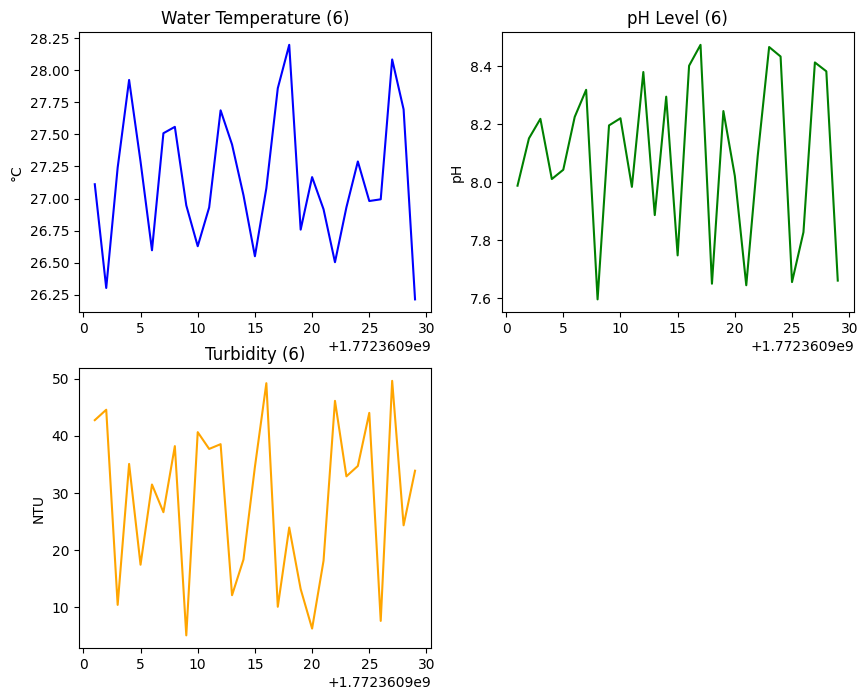

In [6]:
consumer = initialize_consumer()
print("Subscribed to Kafka topic 'water_quality'.")

try:
    while True:
        update_plot(consumer)
except KeyboardInterrupt:
    print("Stopped visualization.")
    consumer.close()